In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay


In [37]:
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
svm_linear = SVC(
    kernel="linear",
    random_state=42
)

svm_linear.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [40]:
train_pred = svm_linear.predict(X_train)
test_pred = svm_linear.predict(X_test)

In [41]:
train_f1 = f1_score(y_train, train_pred)
test_f1 = f1_score(y_test, test_pred)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")

print(f"\nTrain F1 Score : {train_f1:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")

Train Accuracy : 0.9912
Test Accuracy  : 0.9737

Train F1 Score : 0.9930
Test F1 Score  : 0.9790


In [42]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [43]:
cm = confusion_matrix(y_test, test_pred)
print(cm)

[[41  1]
 [ 2 70]]


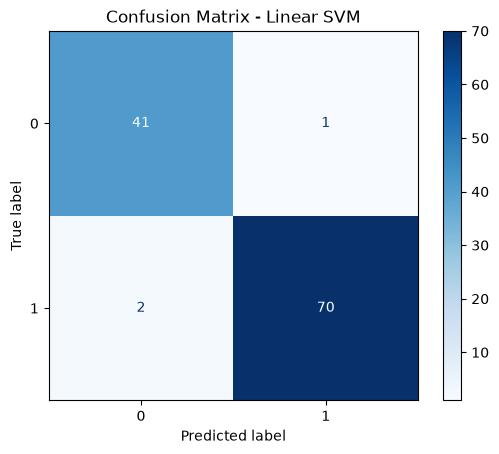

In [44]:
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

# Summary

A Support Vector Machine (SVM) classifier with a linear kernel was trained on the Breast Cancer Wisconsin dataset. Before training, the features were standardized using StandardScaler since SVM is sensitive to the scale of the input features.

The model achieved a **training accuracy of 99.12%** and a **testing accuracy of 97.37%**. The **training F1 score was 0.9930**, while the **testing F1 score reached 0.9790**.

The confusion matrix shows that the model correctly classified most samples, making only **3 misclassifications out of 114 test samples**. The small difference between the training and testing performance indicates that the model generalizes well to unseen data and does not exhibit significant overfitting or underfitting.

**Final Results:**
- Train Accuracy: **99.12%**
- Test Accuracy: **97.37%**
- Train F1 Score: **0.9930**
- Test F1 Score: **0.9790**

**Conclusion:**
The Linear SVM classifier achieved excellent classification performance on this dataset. The high F1 score and the low number of classification errors demonstrate that the dataset is nearly linearly separable, making the linear kernel an effective choice.